## Support Vector Classifier Implementation



In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')



In [58]:
## Lets create an sythetic dataset for imbalanced classification problem
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_clusters_per_class=2, n_redundant=0)


In [59]:
X.shape

(1000, 2)

In [60]:
X

array([[ 1.10008476,  1.0812939 ],
       [ 0.80052736, -1.32192642],
       [ 1.42370968,  0.56438346],
       ...,
       [-1.87054551,  1.5217713 ],
       [-0.40065722,  0.31543091],
       [ 1.02836525, -1.97427107]])

In [61]:
y

array([1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,

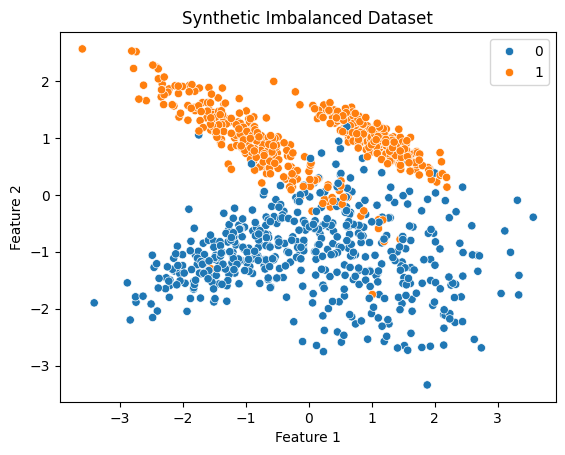

In [62]:
## plotting the dataset to visualize the imbalance
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)
plt.title('Synthetic Imbalanced Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.show()  

In [63]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [64]:
from sklearn.svm import SVC
svc = SVC(kernel= 'linear')
svc.fit(X_train, y_train)

SVC(kernel='linear')

In [65]:
svc.coef_

array([[-0.01839718,  2.22168635]])

In [66]:
## Prediction
y_pred = svc.predict(X_test)


In [67]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       131
           1       0.93      0.95      0.94       119

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250

[[123   8]
 [  6 113]]


In [68]:
## Now using another kernel
svc_rbf = SVC(kernel= 'rbf')
svc_rbf.fit(X_train, y_train)
y_pred_rbf = svc_rbf.predict(X_test)
print(classification_report(y_test, y_pred_rbf))
print(confusion_matrix(y_test, y_pred_rbf))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       131
           1       0.93      0.94      0.93       119

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250

[[122   9]
 [  7 112]]


In [69]:
## using polynomial kernel
svc_poly = SVC(kernel= 'poly')
svc_poly.fit(X_train, y_train)
y_pred_poly = svc_poly.predict(X_test)
print(classification_report(y_test, y_pred_poly))
print(confusion_matrix(y_test, y_pred_poly))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       131
           1       0.97      0.90      0.93       119

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250

[[128   3]
 [ 12 107]]


In [70]:
## Sigmoid kernel is not available in sklearn, but we can use the 'sigmoid' kernel which is similar to sigmoid function
svc_sigmoid = SVC(kernel= 'sigmoid')
svc_sigmoid.fit(X_train, y_train)
y_pred_sigmoid = svc_sigmoid.predict(X_test)
print(classification_report(y_test, y_pred_sigmoid))
print(confusion_matrix(y_test, y_pred_sigmoid))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89       131
           1       0.88      0.87      0.87       119

    accuracy                           0.88       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250

[[117  14]
 [ 16 103]]


## Hyperparameter Tuning with SVC

In [72]:
from sklearn.model_selection import GridSearchCV

## Hyperparameter tuning using GridSearchCV and defining a parameter for SVC
param_grid = {'C': [0.1, 1, 10, 100, 1000],
                'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                'kernel': ['rbf', 'poly', 'sigmoid']}

grid = GridSearchCV(SVC(), param_grid=param_grid, refit=True, cv=5, verbose=3)

In [73]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.967 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.933 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.920 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.920 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.907 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.953 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.840 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=1, kernel=sigmoid

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'poly', 'sigmoid']},
             verbose=3)

In [74]:
grid.best_params_ ## best parameters after tuning 

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [75]:
## Prdiction and evaluation after hyperparameter tuning
y_pred_grid = grid.predict(X_test)
print(classification_report(y_test, y_pred_grid))
print(confusion_matrix(y_test, y_pred_grid))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       131
           1       0.97      0.93      0.95       119

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250

[[127   4]
 [  8 111]]
